# AIS Feed — Dataset Observations

What `ship_positions.json` actually contains, and how it shaped the design.

These are observations about the supplied data, recorded because decisions rest on them.
They describe what the file holds, not what it ought to hold. Every figure here is
computed live from the feed; the arithmetic lives in `feed_stats.py`, which the markdown
report `docs/dataset-observations.md` also imports, so the two cannot disagree.

**The short version.** The obvious primary key destroys 87% of the feed, and the obvious
sort order is meaningless. Sections 3 and 5 are the ones that matter.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

import feed_stats as fs

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

records = fs.load()
mmsis = fs.vessels(records)
print(f"{len(records):,} records loaded from {fs.FEED.name}")

Matplotlib is building the font cache; this may take a moment.


2,696 records loaded from ship_positions.json


## 1. Shape

In [2]:
shape = fs.shape(records)
print(f"{shape['records']:,} records | {shape['vessels']} vessels | "
      f"{shape['distinct_station_ids']:,} distinct stationId")
print(f"{shape['span_hours']:.1f} hours: {shape['first']} to {shape['last']} UTC")
print(f"All {shape['fields']} fields present on every record; no nulls.")

pd.DataFrame([
    {
        "mmsi": m,
        "records": len([r for r in records if r["mmsi"] == m]),
        "lat range": f"{min(r['lat'] for r in records if r['mmsi']==m):.2f} to {max(r['lat'] for r in records if r['mmsi']==m):.2f}",
        "lon range": f"{min(r['lon'] for r in records if r['mmsi']==m):.2f} to {max(r['lon'] for r in records if r['mmsi']==m):.2f}",
    }
    for m in mmsis
]).set_index("mmsi")

2,696 records | 3 vessels | 2,696 distinct stationId
18.2 hours: 2013-06-30 23:34 to 2013-07-01 17:44 UTC
All 10 fields present on every record; no nulls.


,records,lat range,lon range
mmsi,,,
247039300,869,39.49 to 44.27,13.87 to 19.16
311040700,967,33.56 to 34.84,31.38 to 35.54
311486000,860,36.26 to 38.24,10.83 to 15.97


## 2. `stationId` is a record identifier, not a receiving station

The field is named for a receiving station. It does not behave like one.

In [3]:
facts = fs.report_id_facts(records)
print(f"Unique across all {len(records):,} records : {facts['unique']}")
print(f"Range                              : {facts['minimum']}-{facts['maximum']}, with gaps")
print(f"Strictly ascending in file order   : {facts['ascending_in_file_order']}")

Unique across all 2,696 records : True
Range                              : 81-3396, with gaps
Strictly ascending in file order   : True


No value repeats even once across 18 hours and three vessels. A receiving station that
heard exactly one message and never another does not exist; a monotonic record counter does.

**This is why the primary key is `report_id`** — see ADR-0001.

## 3. `(mmsi, timestamp)` is not unique, and the duplicates conflict

This is the finding that set the primary key. The obvious composite key looks natural and
is catastrophic here.

In [ ]:
c = fs.conflicts(records) # Reports sharing an MMSI and a Reported Time but disagreeing about position.
print(f"Distinct (mmsi, timestamp) pairs   : {c['distinct_pairs']} across {len(records):,} records")
print(f"Keys carrying more than one report : {c['repeated_keys']}")
print(f"Of those, exact duplicates         : {c['exact_duplicates']}")
print(f"Busiest single key                 : {c['busiest_key_size']} reports")
print()
print(f"Records lost to last-write-wins    : {c['records_lost']:,}  ({c['share_lost']:.1%})")

Distinct (mmsi, timestamp) pairs   : 345 across 2,696 records
Keys carrying more than one report : 142
Of those, exact duplicates         : 0
Busiest single key                 : 119 reports

Records lost to last-write-wins    : 2,351  (87.2%)


Not a rounding error — **seven eighths of the feed**, discarded silently while the ingest
counter reports every record written.

They are not near-duplicates either. Here is the widest disagreement: one vessel, one second,
two positions.

mmsi 247039300 @ 1372696620 -> stationId  734 | 44.05453, 14.07790 | speed 15.6 kn
mmsi 247039300 @ 1372696620 -> stationId 1643 | 40.57935, 18.21955 | speed 16.1 kn

separation: 515 km


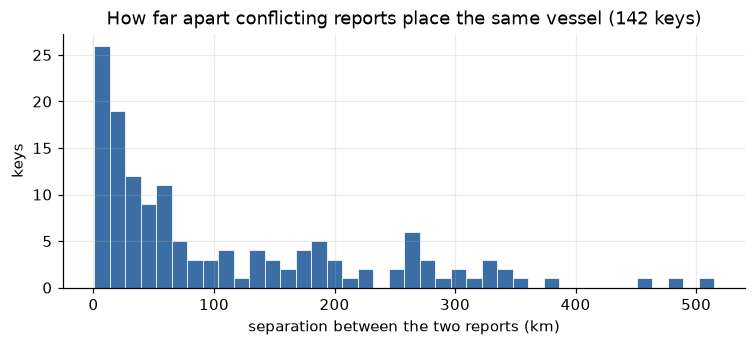

In [5]:
for r in c["widest_pair"]:
    print(f"mmsi {r['mmsi']} @ {r['timestamp']} -> stationId {r['stationId']:>4} | "
          f"{r['lat']:.5f}, {r['lon']:.5f} | speed {r['speed']/10:.1f} kn")
print(f"\nseparation: {fs.haversine_km(*c['widest_pair']):.0f} km")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(c["separations_km"], bins=40, color="#3b6ea5", edgecolor="white", linewidth=0.5)
ax.set_xlabel("separation between the two reports (km)")
ax.set_ylabel("keys")
ax.set_title(f"How far apart conflicting reports place the same vessel ({c['repeated_keys']} keys)")
plt.show()

**Both reports are kept.** A Position Report records what arrived, not where the vessel
truly was, so the store has no basis for choosing between them — ADR-0001.

## 4. Reported Time is heavily degenerate

The timestamps are not a continuous clock. They are a coarse grid, unevenly loaded.

Distinct timestamp values            : 219 across 2,696 records
Every gap a multiple of 60 seconds   : True
Busiest single value                 : 1372700580 (2013-07-01 17:43) carries 272 records

  at that one second, mmsi 247039300:  69 records spanning lat 39.50-44.24, lon 13.89-19.15
  at that one second, mmsi 311040700:  84 records spanning lat 33.64-34.82, lon 31.46-35.54
  at that one second, mmsi 311486000: 119 records spanning lat 36.26-38.21, lon 11.00-15.97


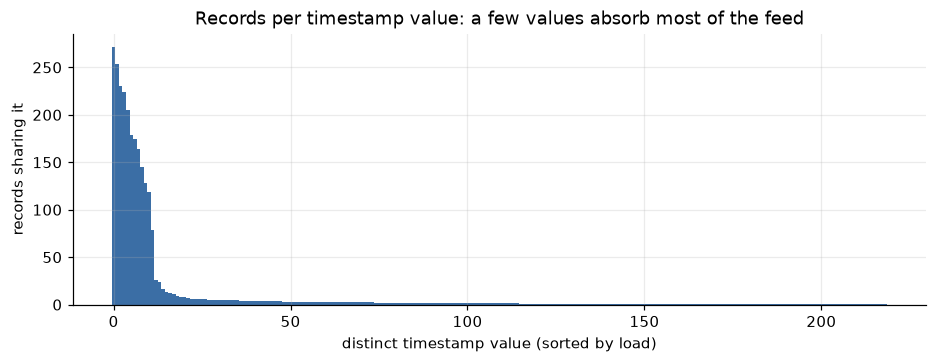

In [ ]:
t = fs.timestamp_facts(records)
print(f"Distinct timestamp values            : {t['distinct']} across {len(records):,} records")
print(f"Every gap a multiple of 60 seconds   : {t['all_gaps_minute_multiples']}")
print(f"Busiest single value                 : {t['busiest']} ({t['busiest_label']}) "
      f"carries {t['busiest_count']} records")
print()
for m in mmsis:
    rows = [r for r in records if r["mmsi"] == m and r["timestamp"] == t["busiest"]]
    if rows:
        print(f"  at that one second, mmsi {m}: {len(rows):>3} records spanning "
              f"lat {min(r['lat'] for r in rows):.2f}-{max(r['lat'] for r in rows):.2f}, "
              f"lon {min(r['lon'] for r in rows):.2f}-{max(r['lon'] for r in rows):.2f}")

fig, ax = plt.subplots(figsize=(10, 3.2))
counts = sorted(t["counts"].values(), reverse=True)
ax.bar(range(len(counts)), counts, color="#3b6ea5", width=1.0) # X axis is index of timestamp value, Y is num of records sharing it
ax.set_xlabel("distinct timestamp value (sorted by load)")
ax.set_ylabel("records sharing it")
ax.set_title("Records per timestamp value: a few values absorb most of the feed")
plt.show()

A one-minute time filter can legitimately return hundreds of reports scattered across the
whole Mediterranean. **That is a property of the data, not a bug in the API** — worth saying
plainly in the README, because it looks like the latter.

It also makes real-time replay undefined: there are no meaningful inter-arrival gaps to
honour, which is why the producer paces at a fixed rate instead.

## 5. Ordering by `stationId` recovers coherent voyages; by timestamp it does not

The centrepiece. Same records, same vessels — only the sort order differs.

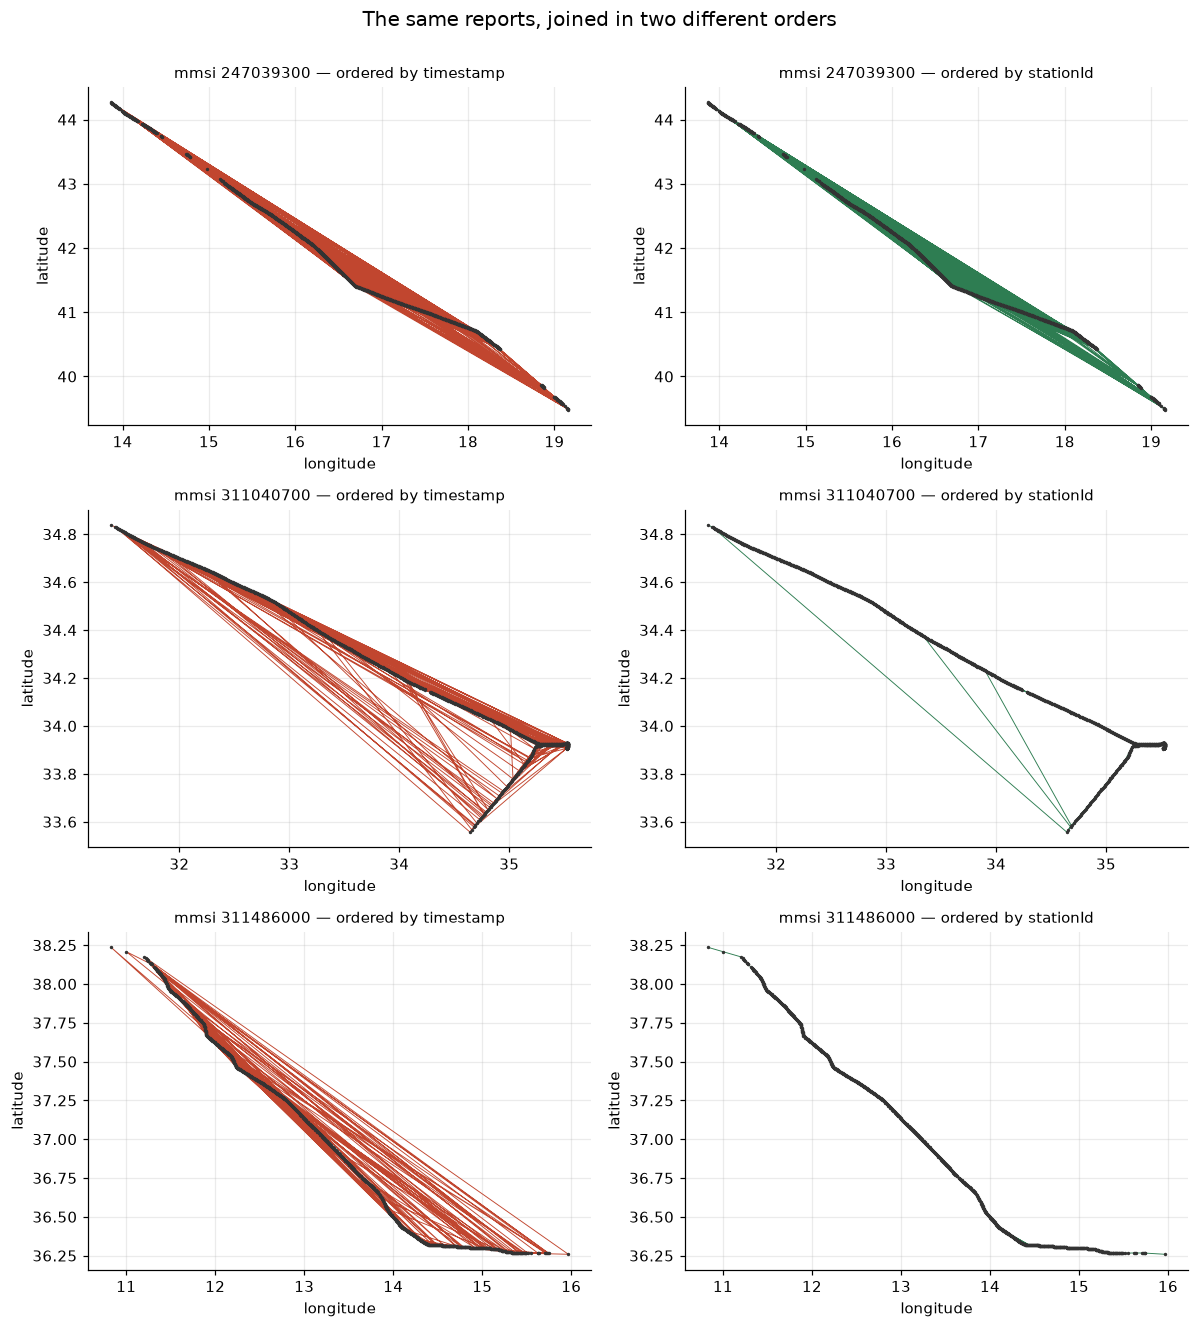

In [7]:
fig, axes = plt.subplots(len(mmsis), 2, figsize=(11, 4 * len(mmsis)))
for row, m in enumerate(mmsis):
    for col, ordering in enumerate(("timestamp", "stationId")):
        ax = axes[row][col]
        pts = fs.track(records, m, ordering)
        ax.plot([p["lon"] for p in pts], [p["lat"] for p in pts],
                linewidth=0.6, color="#c1462f" if ordering == "timestamp" else "#2e7d52")
        ax.scatter([p["lon"] for p in pts], [p["lat"] for p in pts], s=1.5, color="#333", zorder=3)
        ax.set_title(f"mmsi {m} — ordered by {ordering}", fontsize=10)
        ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
fig.suptitle("The same reports, joined in two different orders", fontsize=13, y=1.002)
fig.tight_layout()
plt.show()

The left column is noise. The right column, for the lower two vessels, is a voyage.

Quantified — the distance between consecutive reports along each track:

In [8]:
pd.DataFrame(fs.ordering_comparison(records)).pivot(
    index="mmsi", columns="ordering",
    values=["total_path_km", "median_hop_km", "p95_hop_km"]
).round(2)

total_path_km            median_hop_km           p95_hop_km  \
ordering      stationId  timestamp     stationId timestamp  stationId   
mmsi                                                                    
247039300      94420.99  112972.60         45.24     79.06     395.31   
311040700       1703.21   41070.30          0.60     10.90       3.79   
311486000        597.18   33516.58          0.51      7.30       0.76   

                     
ordering  timestamp  
mmsi                 
247039300    410.97  
311040700    263.74  
311486000    270.65

Independent corroboration, from a completely different direction: take each report's own
reported Speed, and ask how long it would need to reach the next report in `stationId` order.
If that ordering is the true receipt sequence, the answer should land near the 60-second grid
the timestamps use.

In [9]:
for m, seconds in fs.implied_intervals(records).items():
    verdict = "matches the 60s grid" if seconds < 200 else "no coherent interval"
    print(f"mmsi {m}: median {seconds:>6.0f} s   {verdict}")

mmsi 247039300: median   5601 s   no coherent interval
mmsi 311040700: median     79 s   matches the 60s grid
mmsi 311486000: median     67 s   matches the 60s grid


Two of three land at 67 and 79 seconds, against a grid of 60. Nothing forced that agreement —
it falls out of the reported speeds, which were never used to construct the ordering.

**MMSI 247039300 stays incoherent under both orderings.** That is consistent with two vessels
sharing one MMSI, a real AIS phenomenon: misconfigured transponders do collide. Not
investigated further, because it changes no decision here.

**This is why results are ordered by Report ID** — see ADR-0006. An API that sorted by
Reported Time would look conventional and return an arbitrary ordering.

## 6. Field ranges

In [10]:
f = fs.field_ranges(records)
print(f"speed   : {f['speed'][0]}-{f['speed'][1]}   knots x10, so a maximum of {f['speed'][1]/10:.1f} kn")
print(f"course  : {f['course'][0]}-{f['course'][1]}  whole degrees, NOT the decidegrees AIS uses on the wire")
print(f"heading : {f['heading'][0]}-{f['heading'][1]}  whole degrees")
print(f"rot     : {f['rot']}   the empty string in every single record")
print(f"status  : {f['status']}   navigational status")

speed   : 0-199   knots x10, so a maximum of 19.9 kn
course  : 10-355  whole degrees, NOT the decidegrees AIS uses on the wire
heading : 4-357  whole degrees
rot     : {'': 2696}   the empty string in every single record
status  : {0: 2616, 5: 80}   navigational status


Only `speed` carries the AIS x10 scaling; `course` and `heading` are plain degrees. Guessing
that all three were scaled would have silently divided two of them by ten.

`rot` never carries a value, so its column type comes from the AIS specification (signed,
-128..127) rather than from the data — and a `NOT NULL` column would reject the entire
dataset. See ADR-0002.

## What these observations changed

| Observation | Decision |
| --- | --- |
| `stationId` unique and monotonic; `(mmsi, timestamp)` collapses 87% of the feed | Report ID is the primary key, and the idempotency mechanism — ADR-0001 |
| Conflicting reports are real and irreconcilable | Append-only observation log; the store never adjudicates — ADR-0001 |
| Only `speed` is scaled; `rot` is always empty | Normalise units at ingest; `rot` nullable from the spec, not the data — ADR-0002 |
| Reported Time is degenerate, `stationId` is not | Results ordered by Report ID, no sort-by-time option — ADR-0006 |
| No meaningful inter-arrival gaps | Producer paces at a fixed rate; real-time replay explicitly rejected |